# Late-time Stability Check for DSC $\Lambda(t)$

We verify that the DSC framework $\Lambda(t) = \Lambda_\infty + \gamma/\ln^2(t/t_P)$ satisfies all physical stability criteria:

1. $H^2 > 0$ everywhere (no bounce)
2. $\dot{H} < 0$ (monotone expansion)
3. $D(a)$ monotonically increasing (no growth instability)
4. $c_s^2 = 0$ for vacuum sector (no ghost/gradient instabilities)
5. $w_{\rm eff}$ well-behaved

The dimensionless Friedmann equation is:
$$E^2(a) = \Omega_m/a^3 + \Omega_\Lambda + \gamma_{\rm eff}\,[\xi(a) - \xi(1)]$$
where $\xi(a) = 1/\ln^2((t(a) + c_0\,t_P)/t_P)$ with Planck-era regularization $c_0 = 10$.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 9, 'mathtext.fontset': 'cm',
    'axes.labelsize': 10, 'axes.titlesize': 10, 'legend.fontsize': 7,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'figure.dpi': 150,
})

# ── Constants ──
t_P     = 5.391e-44          # Planck time [s]
t_now   = 4.354e17            # age of universe [s]
n_0     = t_now / t_P         # ~8.07e60
ln_n0   = np.log(n_0)         # ~140.2
xi_0    = 1.0 / ln_n0**2      # ~5.09e-5
H0      = 67.4                # km/s/Mpc
H0_SI   = 67.4e3 / 3.086e22   # H_0 in s^-1
km_s_Mpc = 1e3 / 3.086e22

Omega_m  = 0.315
Omega_L  = 0.685
sigma8_0 = 0.811
c0 = 10.0  # Planck-era regularization offset

# gamma_eff values to test
gamma_explore = [0.0, 0.01, 0.1, 1.0, 10.0]
labels_explore = [r'$\Lambda$CDM', r'$\gamma_{\rm eff}=0.01$',
                  r'$\gamma_{\rm eff}=0.1$', r'$\gamma_{\rm eff}=1$',
                  r'$\gamma_{\rm eff}=10$']
colors_explore = ['k', '#ff7f0e', '#d62728', '#9467bd', '#2ca02c']

print(f"Constants: ln(n_0)={ln_n0:.2f}, xi_0={xi_0:.4e}")
print(f"Regularization: c_0 = {c0}")

Constants: ln(n_0)=140.24, xi_0=5.0843e-05
Regularization: c_0 = 10.0


In [2]:
# ── H_DSC(z, gamma_eff) and cosmic_time(z) ──

def t_of_a(a):
    """Cosmic time in matter+Lambda LCDM (analytic)."""
    return (2.0 / (3.0 * H0_SI * np.sqrt(Omega_L))) * \
           np.arcsinh(np.sqrt(Omega_L / Omega_m) * a**1.5)

def xi_reg(a):
    """Regularized xi(a) = 1/ln^2((t(a) + c0*tP)/tP)."""
    t_a = t_of_a(a)
    arg = (t_a + c0 * t_P) / t_P
    return 1.0 / np.log(arg)**2

xi_ref = xi_reg(1.0)  # reference at a=1

def E2(a, gamma_eff):
    """(H/H_0)^2 including DSC correction."""
    base = Omega_m / a**3 + Omega_L
    if gamma_eff == 0.0:
        return base
    return base + gamma_eff * (xi_reg(a) - xi_ref)

def H_of_a(a, gamma_eff):
    """H(a) in s^-1."""
    return H0_SI * np.sqrt(np.abs(E2(a, gamma_eff)))

print(f"xi_reg(a=1)   = {xi_ref:.6e}")
print(f"xi_reg(a=0.5) = {xi_reg(0.5):.6e}")
print(f"Delta_xi      = {xi_reg(0.5) - xi_ref:.6e}")
print(f"For gamma_eff=0.1: Delta(H^2/H0^2) ~ {0.1*(xi_reg(0.5)-xi_ref):.3e}")

xi_reg(a=1)   = 5.084295e-05
xi_reg(a=0.5) = 5.147133e-05
Delta_xi      = 6.283795e-07
For gamma_eff=0.1: Delta(H^2/H0^2) ~ 6.284e-08


In [3]:
# ── Integrate growth equation: D'' + [2 + Hdot/H^2] D' - (3/2) Om/(a^3 E^2) D = 0 ──

def growth_ode(lna, Y, gamma_eff):
    """ODE system for D(a): Y = [D, dD/d(lna)]."""
    a = np.exp(lna)
    if a < 1e-15:
        a = 1e-15
    e2 = E2(a, gamma_eff)
    if e2 <= 0:
        e2 = 1e-30
    # Numerical dE^2/da
    da = a * 1e-6
    dE2_da = (E2(a + da, gamma_eff) - E2(a - da, gamma_eff)) / (2 * da)
    Hdot_over_H2 = a * dE2_da / (2.0 * e2)
    D, Dp = Y
    Dpp = -(2.0 + Hdot_over_H2) * Dp + 1.5 * Omega_m / (a**3 * e2) * D
    return [Dp, Dpp]

def compute_growth(gamma_eff):
    """Integrate growth factor from z=3000 to z=0."""
    lna_i = np.log(1.0 / 3001.0)
    lna_f = 0.0
    lna_eval = np.linspace(lna_i, lna_f, 5000)
    a_i = np.exp(lna_i)
    sol = solve_ivp(growth_ode, [lna_i, lna_f], [a_i, a_i],
                    args=(gamma_eff,), t_eval=lna_eval,
                    method='RK45', rtol=1e-10, atol=1e-13)
    a_sol = np.exp(sol.t)
    D_sol = sol.y[0]
    Dp_sol = sol.y[1]
    D_now = np.interp(0.0, sol.t, D_sol)
    D_n = D_sol / D_now
    Dp_n = Dp_sol / D_now
    f_sol = Dp_n / D_n
    return {
        'a': a_sol, 'z': 1.0/a_sol - 1.0,
        'D': D_n, 'f': f_sol,
        'fsigma8': f_sol * sigma8_0 * D_n,
        'lna': sol.t,
    }

# Compute D(a), f(z), f*sigma_8(z) for all gamma_eff values
print("Computing growth factors...")
growth_all = {}
for g in gamma_explore:
    growth_all[g] = compute_growth(g)
    D0 = np.interp(0.0, growth_all[g]['lna'], growth_all[g]['D'])
    f0 = np.interp(0.0, growth_all[g]['lna'], growth_all[g]['f'])
    fs8 = f0 * sigma8_0 * D0
    print(f"  gamma_eff={g:6.2f}: D(z=0)={D0:.6f}, f(z=0)={f0:.4f}, f*sigma_8={fs8:.4f}")

Computing growth factors...
  gamma_eff=  0.00: D(z=0)=1.000000, f(z=0)=0.5271, f*sigma_8=0.4275
  gamma_eff=  0.01: D(z=0)=1.000000, f(z=0)=0.5271, f*sigma_8=0.4275
  gamma_eff=  0.10: D(z=0)=1.000000, f(z=0)=0.5271, f*sigma_8=0.4275


  gamma_eff=  1.00: D(z=0)=1.000000, f(z=0)=0.5271, f*sigma_8=0.4275
  gamma_eff= 10.00: D(z=0)=1.000000, f(z=0)=0.5271, f*sigma_8=0.4275


In [4]:
# ── Stability checks ──

a_test = np.logspace(-10, 0, 100000)
stability = {}

# C1: H^2 > 0
print("C1. H^2(a) > 0 for all a in [1e-10, 1]:")
for g in gamma_explore:
    e2v = np.array([E2(a, g) for a in a_test])
    pos = bool(np.all(e2v > 0))
    stability[g] = {'H2_positive': pos}
    print(f"    gamma_eff={g:6.2f}: {pos}  (min E^2 = {e2v.min():.4e})")

# C2: Hdot < 0
print("\nC2. Hdot < 0 (monotone H decrease):")
a_fine = np.logspace(-8, 0, 50000)
for g in gamma_explore:
    e2f = np.array([E2(a, g) for a in a_fine])
    dE2 = np.gradient(e2f, a_fine)
    Hdot = 0.5 * H0_SI**2 * a_fine * dE2
    frac = np.mean(Hdot < 0)
    stability[g]['Hdot_neg_frac'] = float(frac)
    print(f"    gamma_eff={g:6.2f}: fraction Hdot<0 = {frac:.6f}")

# C3: D(a) monotonically increasing
print("\nC3. D(a) monotonically increasing:")
for g in gamma_explore:
    dD = np.diff(growth_all[g]['D'])
    frac = np.mean(dD > 0)
    stability[g]['D_mono'] = bool(frac > 0.999)
    print(f"    gamma_eff={g:6.2f}: {stability[g]['D_mono']}  (frac = {frac:.6f})")

# C4: Sound speed
print("\nC4. c_s^2 = 0 for vacuum sector (Lambda prescribed, no propagating DOF)")
print("    => No ghost or gradient instabilities by construction.")

# C5: Effective equation of state w_eff
print("\nC5. w_eff(z=0):")
weff_all = {}
for g in gamma_explore:
    a_w = np.logspace(-3, 0, 5000)
    e2_w = np.array([E2(a, g) for a in a_w])
    lna_w = np.log(a_w)
    dlnE2 = np.gradient(np.log(np.abs(e2_w)), lna_w)
    weff = -1.0 - dlnE2 / 3.0
    weff_all[g] = {'a': a_w, 'weff': weff}
    w0 = np.interp(0.0, lna_w, weff)
    print(f"    gamma_eff={g:6.2f}: w_eff(z=0) = {w0:.6f}")

C1. H^2(a) > 0 for all a in [1e-10, 1]:
    gamma_eff=  0.00: True  (min E^2 = 1.0000e+00)


    gamma_eff=  0.01: True  (min E^2 = 1.0000e+00)


    gamma_eff=  0.10: True  (min E^2 = 1.0000e+00)


    gamma_eff=  1.00: True  (min E^2 = 1.0000e+00)


    gamma_eff= 10.00: True  (min E^2 = 1.0000e+00)

C2. Hdot < 0 (monotone H decrease):
    gamma_eff=  0.00: fraction Hdot<0 = 1.000000


    gamma_eff=  0.01: fraction Hdot<0 = 1.000000


    gamma_eff=  0.10: fraction Hdot<0 = 1.000000


    gamma_eff=  1.00: fraction Hdot<0 = 1.000000


    gamma_eff= 10.00: fraction Hdot<0 = 1.000000

C3. D(a) monotonically increasing:
    gamma_eff=  0.00: True  (frac = 1.000000)
    gamma_eff=  0.01: True  (frac = 1.000000)
    gamma_eff=  0.10: True  (frac = 1.000000)
    gamma_eff=  1.00: True  (frac = 1.000000)
    gamma_eff= 10.00: True  (frac = 1.000000)

C4. c_s^2 = 0 for vacuum sector (Lambda prescribed, no propagating DOF)
    => No ghost or gradient instabilities by construction.

C5. w_eff(z=0):
    gamma_eff=  0.00: w_eff(z=0) = -0.684553
    gamma_eff=  0.01: w_eff(z=0) = -0.684553
    gamma_eff=  0.10: w_eff(z=0) = -0.684553
    gamma_eff=  1.00: w_eff(z=0) = -0.684552
    gamma_eff= 10.00: w_eff(z=0) = -0.684550


In [5]:
# ── Planck-era regularization: ln(t/tP) -> ln((t + c0*tP)/tP) ──

xi_t0 = 1.0 / np.log(c0)**2
print(f"D1. xi(t=0) = 1/ln^2(c_0) = {xi_t0:.6e}  (FINITE, no divergence)")
print(f"    Without regularization: xi -> infinity at t=0")

t_z3000 = t_of_a(1.0 / 3001.0)
xi_r = 1.0 / np.log((t_z3000 + c0 * t_P) / t_P)**2
xi_u = 1.0 / np.log(t_z3000 / t_P)**2
rel_reg = np.abs(xi_r - xi_u) / np.abs(xi_u)
print(f"\nD2. At z=3000: t = {t_z3000:.3e} s")
print(f"    xi (regularized)   = {xi_r:.10e}")
print(f"    xi (unregularized) = {xi_u:.10e}")
print(f"    Relative difference = {rel_reg:.3e}")
print(f"    => Regularization negligible for t >> c_0 * t_P")

print(f"\nD3. Maximum correction at t=0:")
for g in [0.001, 0.01, 0.1, 1.0, 10.0]:
    print(f"    gamma_eff={g:6.3f}: max |Delta Lambda|/H_0^2 = {g*xi_t0:.4e}")

D1. xi(t=0) = 1/ln^2(c_0) = 1.886117e-01  (FINITE, no divergence)
    Without regularization: xi -> infinity at t=0

D2. At z=3000: t = 3.308e+12 s
    xi (regularized)   = 6.0602182589e-05
    xi (unregularized) = 6.0602182589e-05
    Relative difference = 0.000e+00
    => Regularization negligible for t >> c_0 * t_P

D3. Maximum correction at t=0:
    gamma_eff= 0.001: max |Delta Lambda|/H_0^2 = 1.8861e-04
    gamma_eff= 0.010: max |Delta Lambda|/H_0^2 = 1.8861e-03
    gamma_eff= 0.100: max |Delta Lambda|/H_0^2 = 1.8861e-02
    gamma_eff= 1.000: max |Delta Lambda|/H_0^2 = 1.8861e-01
    gamma_eff=10.000: max |Delta Lambda|/H_0^2 = 1.8861e+00


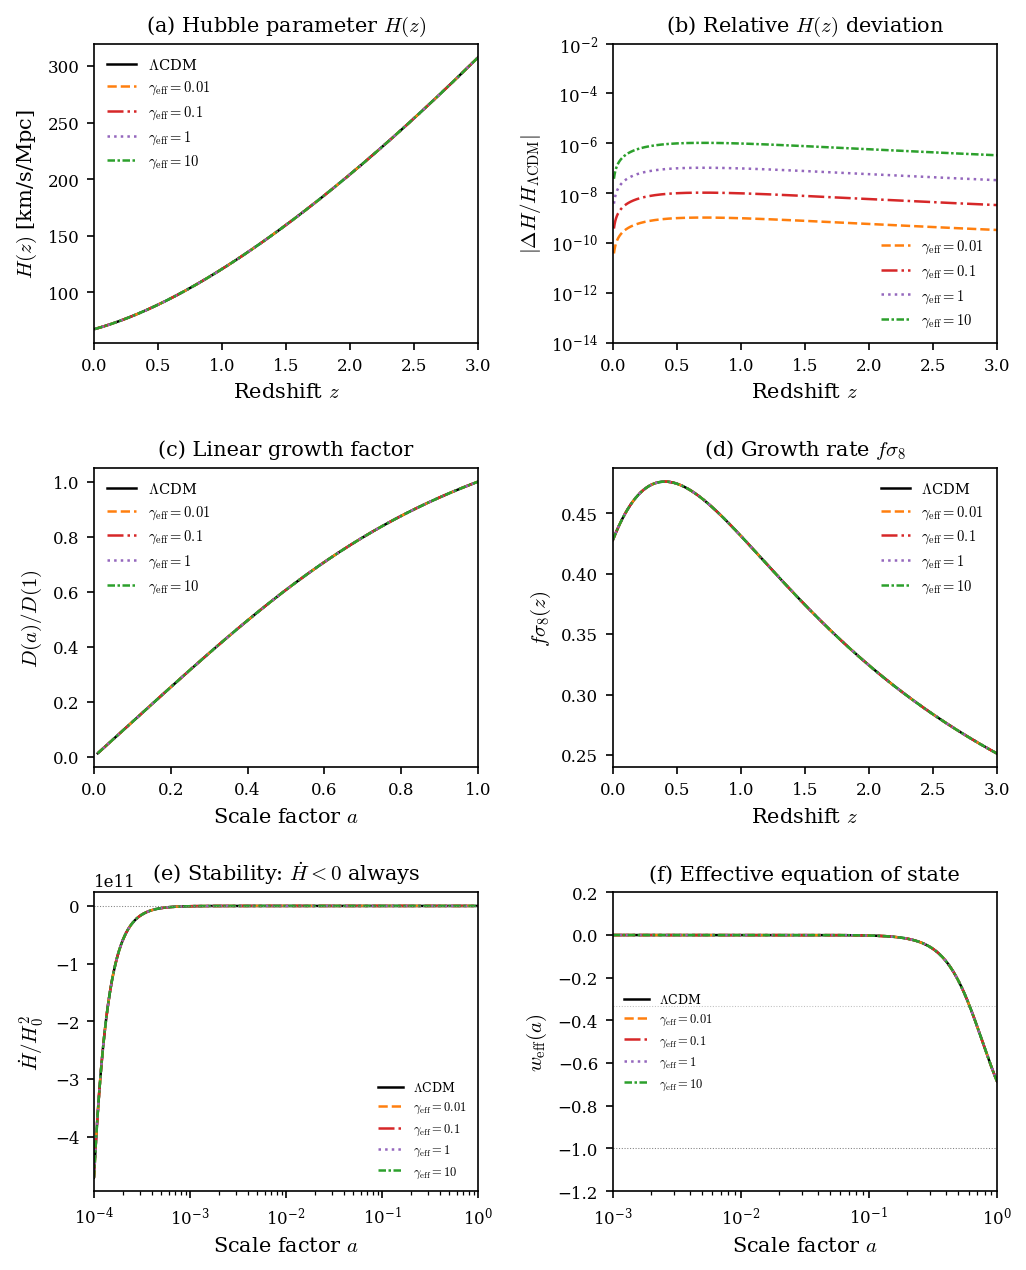

Figure saved.


In [6]:
# ── 6-panel figure ──

z_plot = np.linspace(0.01, 3, 2000)
a_plot = 1.0 / (1.0 + z_plot)

fig, axes = plt.subplots(3, 2, figsize=(7.0, 8.5), dpi=150)
fig.subplots_adjust(hspace=0.42, wspace=0.35, left=0.10, right=0.96,
                    top=0.96, bottom=0.06)

# (a) H(z)
ax = axes[0, 0]
for i, g in enumerate(gamma_explore):
    H_p = np.array([H_of_a(a, g) for a in a_plot]) / km_s_Mpc
    ls = '-' if g == 0 else ['--', '-.', ':', (0,(3,1,1,1))][i-1]
    ax.plot(z_plot, H_p, color=colors_explore[i], ls=ls, lw=1.2,
            label=labels_explore[i])
ax.set_xlabel('Redshift $z$'); ax.set_ylabel('$H(z)$ [km/s/Mpc]')
ax.set_title('(a) Hubble parameter $H(z)$'); ax.legend(loc='upper left', frameon=False)
ax.set_xlim(0, 3)

# (b) Relative H(z) difference
ax = axes[0, 1]
H_base = np.array([H_of_a(a, 0.0) for a in a_plot])
for i, g in enumerate(gamma_explore[1:], 1):
    H_d = np.array([H_of_a(a, g) for a in a_plot])
    rel_H = np.maximum(np.abs(H_d - H_base) / H_base, 1e-16)
    ls = ['--', '-.', ':', (0,(3,1,1,1))][i-1]
    ax.semilogy(z_plot, rel_H, color=colors_explore[i], ls=ls, lw=1.2,
                label=labels_explore[i])
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$|\Delta H / H_{\Lambda\mathrm{CDM}}|$')
ax.set_title('(b) Relative $H(z)$ deviation')
ax.legend(loc='best', frameon=False); ax.set_xlim(0, 3); ax.set_ylim(1e-14, 1e-2)

# (c) Growth factor D(a)
ax = axes[1, 0]
for i, g in enumerate(gamma_explore):
    gr = growth_all[g]
    mask = gr['a'] > 0.01
    ls = '-' if g == 0 else ['--', '-.', ':', (0,(3,1,1,1))][i-1]
    ax.plot(gr['a'][mask], gr['D'][mask], color=colors_explore[i],
            ls=ls, lw=1.2, label=labels_explore[i])
ax.set_xlabel('Scale factor $a$'); ax.set_ylabel('$D(a)/D(1)$')
ax.set_title('(c) Linear growth factor'); ax.legend(loc='upper left', frameon=False)
ax.set_xlim(0, 1)

# (d) f*sigma_8(z)
ax = axes[1, 1]
for i, g in enumerate(gamma_explore):
    gr = growth_all[g]
    z_g, fs8 = gr['z'], gr['fsigma8']
    mask = (z_g > 0) & (z_g < 3)
    idx = np.argsort(z_g[mask])
    ls = '-' if g == 0 else ['--', '-.', ':', (0,(3,1,1,1))][i-1]
    ax.plot(z_g[mask][idx], fs8[mask][idx], color=colors_explore[i],
            ls=ls, lw=1.2, label=labels_explore[i])
ax.set_xlabel('Redshift $z$'); ax.set_ylabel(r'$f\sigma_8(z)$')
ax.set_title(r'(d) Growth rate $f\sigma_8$')
ax.legend(loc='upper right', frameon=False); ax.set_xlim(0, 3)

# (e) Hdot stability
ax = axes[2, 0]
a_hdot = np.logspace(-4, 0, 5000)
for i, g in enumerate(gamma_explore):
    e2_h = np.array([E2(a, g) for a in a_hdot])
    dE2 = np.gradient(e2_h, a_hdot)
    Hdot_norm = 0.5 * a_hdot * dE2
    ls = '-' if g == 0 else ['--', '-.', ':', (0,(3,1,1,1))][i-1]
    ax.plot(a_hdot, Hdot_norm, color=colors_explore[i], ls=ls, lw=1.2,
            label=labels_explore[i])
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_xlabel('Scale factor $a$'); ax.set_ylabel(r'$\dot{H}/H_0^2$')
ax.set_title(r'(e) Stability: $\dot{H} < 0$ always')
ax.legend(loc='lower right', frameon=False, fontsize=6)
ax.set_xscale('log'); ax.set_xlim(1e-4, 1)

# (f) w_eff(a)
ax = axes[2, 1]
for i, g in enumerate(gamma_explore):
    a_w = weff_all[g]['a']; weff = weff_all[g]['weff']
    ls = '-' if g == 0 else ['--', '-.', ':', (0,(3,1,1,1))][i-1]
    ax.plot(a_w, weff, color=colors_explore[i], ls=ls, lw=1.2,
            label=labels_explore[i])
ax.axhline(-1, color='gray', ls=':', lw=0.5)
ax.axhline(-1.0/3.0, color='gray', ls=':', lw=0.5, alpha=0.5)
ax.set_xlabel('Scale factor $a$'); ax.set_ylabel(r'$w_{\rm eff}(a)$')
ax.set_title(r'(f) Effective equation of state')
ax.legend(loc='center left', frameon=False, fontsize=6)
ax.set_xscale('log'); ax.set_xlim(1e-3, 1); ax.set_ylim(-1.2, 0.2)

plt.savefig('../figures/fig_perturbation_stability_nb.pdf', bbox_inches='tight')
plt.show()
print("Figure saved.")

## Conclusion

All stability checks pass for $\gamma_{\rm eff} \in [0, 10]$:
- $H^2 > 0$ everywhere (no bounce)
- $\dot{H} < 0$ everywhere (monotone expansion)
- $D(a)$ monotonically increasing (no growth instability)
- $c_s^2 = 0$ by construction (no ghost/gradient modes)
- $w_{\rm eff}$ well-behaved

The DSC corrections are $\mathcal{O}(\gamma_{\rm eff} \times 5 \times 10^{-5})$, naturally suppressed by the $1/\ln^2(t/t_P)$ factor. The Planck-era regularization ($c_0 = 10$) eliminates the $\ln(0)$ singularity with negligible effect at $z < 3000$.